In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

%matplotlib widget
import matplotlib.pyplot as plt




def find_project_root(start=Path.cwd()):
    """
    Walk upward until we find a project root marker.
    """
    markers = [".git", "pyproject.toml", "setup.py"]

    current = start.resolve()

    while current != current.parent:
        for marker in markers:
            if (current / marker).exists():
                return current
        current = current.parent

    raise RuntimeError("Project root not found")


PROJECT_ROOT = find_project_root()

EXPERIMENT_DIR = PROJECT_ROOT / "data" / "experiments"
SETTINGS_DIR = EXPERIMENT_DIR / "settings"


def load_experiment(run_id):
    matches = [p for p in EXPERIMENT_DIR.iterdir() if p.is_dir() and run_id in p.name]

    if not matches:
        raise RuntimeError(f"No experiment found for run_id '{run_id}'")

    if len(matches) > 1:
        raise RuntimeError(f"Multiple matches for run_id '{run_id}'")

    exp_dir = matches[0]

    # extract settings hash from folder name
    settings_hash = exp_dir.name.split("__")[1]

    csv_path = exp_dir / "experiment_data.csv"
    params_path = SETTINGS_DIR / settings_hash / "params.json"

    df = pd.read_csv(csv_path)

    with open(params_path) as f:
        params = json.load(f)

    return df, params, exp_dir

In [6]:
run_ids = [
    "20260306_130730",
    "20260306_131709",
    "20260306_135810"
]

dfs = {}
params_dict = {}

for run_id in run_ids:
    df, params, path = load_experiment(run_id)

    dfs[run_id] = df
    params_dict[run_id] = params

    
for run_id, params in params_dict.items():
    print(f"\n=== Parameters for run {run_id} ===")
    
    for k, v in params.items():
        display(f"{k:25s}: {v}")


=== Parameters for run 20260306_130730 ===


'axial_cutting_depth_mm   : 1.0'

'dt                       : 1e-05'

'feed_per_tooth_mm        : 0.14400000000000002'

'feed_speed_mm_s          : 20.0'

...

'samples_per_period       : 720'

'spindle_spin             : -1'

'tool_diameter_mm         : 20.0'

'tool_radius_mm           : 10.0'

'z_teeth                  : 8'

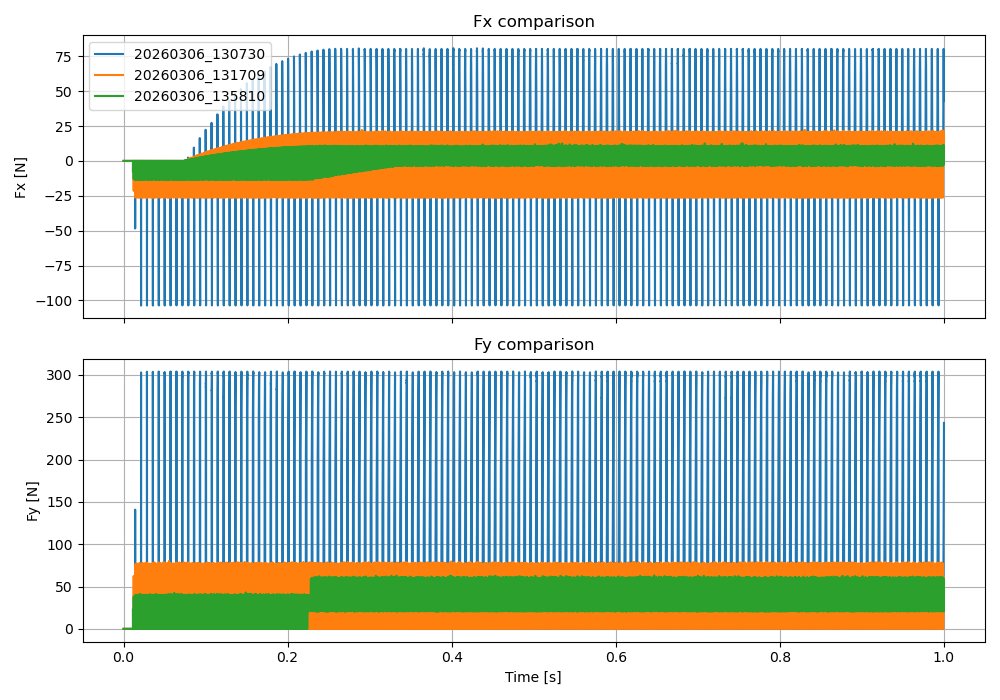

In [7]:
fig, ax = plt.subplots(2,1, figsize=(10,7), sharex=True)

for run_id, df in dfs.items():

    t = df["time_s"]

    ax[0].plot(t, df["fmill_x_N"], label=run_id)
    ax[1].plot(t, df["fmill_y_N"], label=run_id)

ax[0].set_ylabel("Fx [N]")
ax[0].set_title("Fx comparison")
ax[0].grid()
ax[0].legend()

ax[1].set_ylabel("Fy [N]")
ax[1].set_xlabel("Time [s]")
ax[1].set_title("Fy comparison")
ax[1].grid()

plt.tight_layout()

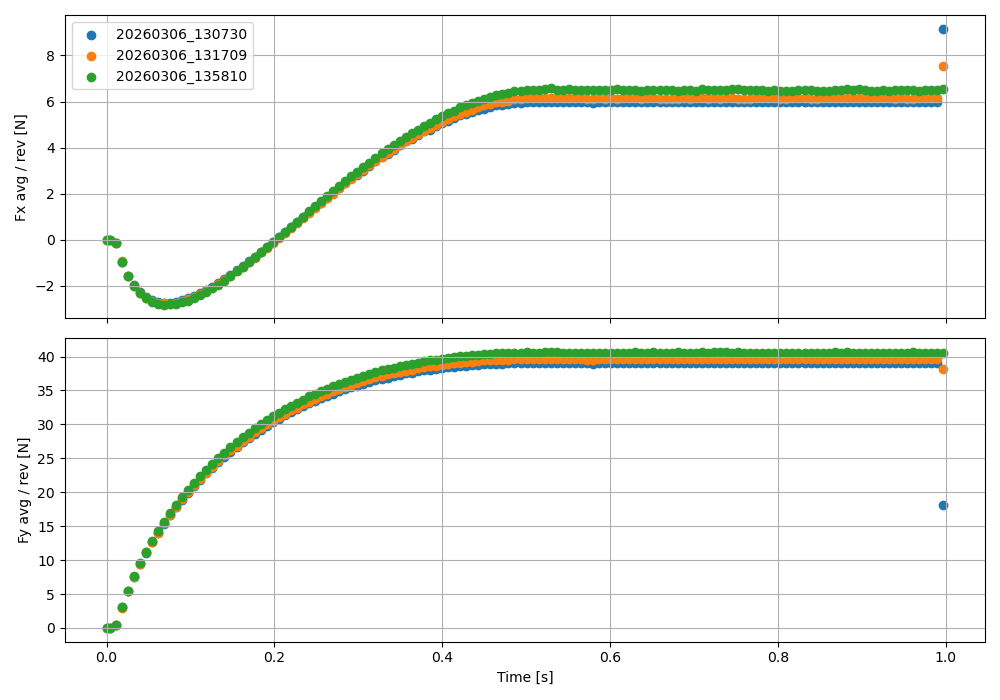

In [8]:
fig, ax = plt.subplots(2,1, figsize=(10,7), sharex=True)

for run_id, df in dfs.items():

    t = df["time_s"].to_numpy()
    phi = df["tool_orientation"].to_numpy()

    fx = df["fmill_x_N"].to_numpy()
    fy = df["fmill_y_N"].to_numpy()

    phi_unwrapped = np.unwrap(phi)
    rev_idx = np.floor((phi_unwrapped - phi_unwrapped[0]) / (2*np.pi)).astype(int)

    df_rev = pd.DataFrame({
        "time_s": t,
        "rev_idx": rev_idx,
        "fx": fx,
        "fy": fy,
    })

    df_rev_avg = df_rev.groupby("rev_idx").mean().reset_index()

    ax[0].scatter(df_rev_avg["time_s"], df_rev_avg["fx"], label=run_id)
    ax[1].scatter(df_rev_avg["time_s"], df_rev_avg["fy"], label=run_id)

ax[0].set_ylabel("Fx avg / rev [N]")
ax[0].grid()
ax[0].legend()

ax[1].set_ylabel("Fy avg / rev [N]")
ax[1].set_xlabel("Time [s]")
ax[1].grid()

plt.tight_layout()

In [10]:
import numpy as np
import pandas as pd

def moving_average_lowpass(x, fs, cutoff_hz=1500.0, mode="3db", min_periods=1):
    """
    Centered moving-average low-pass filter.

    mode:
        "3db"  -> choose window so ~ -3 dB at cutoff_hz
        "zero" -> choose window so first zero is at cutoff_hz
    """
    if mode == "3db":
        window = int(round(0.443 * fs / cutoff_hz))
    elif mode == "zero":
        window = int(round(fs / cutoff_hz))
    else:
        raise ValueError("mode must be '3db' or 'zero'")

    window = max(3, window)
    if window % 2 == 0:
        window += 1  # odd window for symmetric centering

    x_filt = (
        pd.Series(np.asarray(x))
        .rolling(window=window, center=True, min_periods=min_periods)
        .mean()
        .to_numpy()
    )
    return x_filt, window

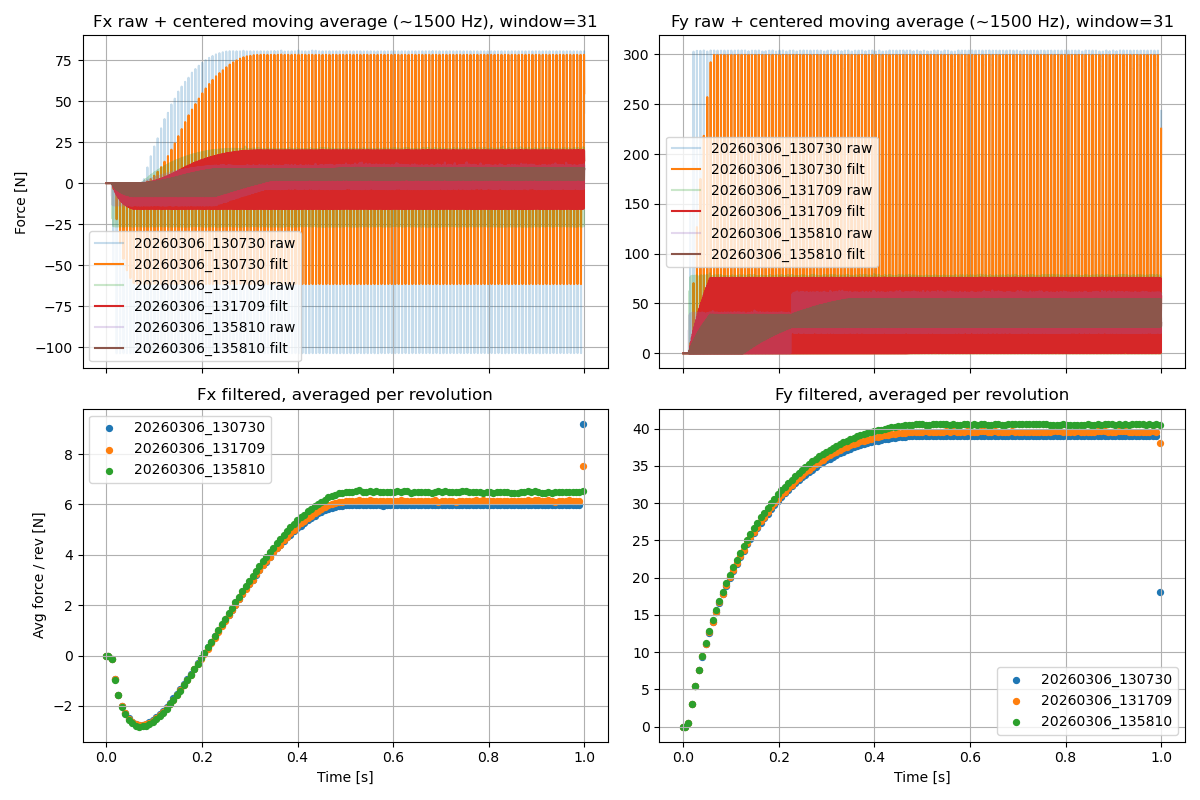

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex='col')

for run_id, df in dfs.items():
    t = df["time_s"].to_numpy()
    phi = df["tool_orientation"].to_numpy()

    fx = df["fmill_x_N"].to_numpy()
    fy = df["fmill_y_N"].to_numpy()

    dt = np.mean(np.diff(t))
    fs = 1.0 / dt

    # centered moving-average filter with approx 1500 Hz cutoff
    fx_filt, window = moving_average_lowpass(fx, fs, cutoff_hz=1500.0, mode="3db")
    fy_filt, _ = moving_average_lowpass(fy, fs, cutoff_hz=1500.0, mode="3db")

    # exact revolution bins from spindle angle
    phi_unwrapped = np.unwrap(phi)
    rev_idx = np.floor((phi_unwrapped - phi_unwrapped[0]) / (2 * np.pi)).astype(int)

    df_rev = pd.DataFrame({
        "time_s": t,
        "rev_idx": rev_idx,
        "fx_filt": fx_filt,
        "fy_filt": fy_filt,
    })

    df_rev_avg = (
        df_rev.groupby("rev_idx", as_index=False)
        .agg(
            time_s=("time_s", "mean"),
            fx_avg=("fx_filt", "mean"),
            fy_avg=("fy_filt", "mean"),
        )
    )

    # Top row: raw + filtered
    ax[0, 0].plot(t, fx, alpha=0.25, label=f"{run_id} raw")
    ax[0, 0].plot(t, fx_filt, linewidth=1.5, label=f"{run_id} filt")

    ax[0, 1].plot(t, fy, alpha=0.25, label=f"{run_id} raw")
    ax[0, 1].plot(t, fy_filt, linewidth=1.5, label=f"{run_id} filt")

    # Bottom row: averaged filtered
    ax[1, 0].scatter(df_rev_avg["time_s"], df_rev_avg["fx_avg"], s=18, label=run_id)
    ax[1, 1].scatter(df_rev_avg["time_s"], df_rev_avg["fy_avg"], s=18, label=run_id)

ax[0, 0].set_title(f"Fx raw + centered moving average (~1500 Hz), window={window}")
ax[0, 1].set_title(f"Fy raw + centered moving average (~1500 Hz), window={window}")
ax[1, 0].set_title("Fx filtered, averaged per revolution")
ax[1, 1].set_title("Fy filtered, averaged per revolution")

ax[0, 0].set_ylabel("Force [N]")
ax[1, 0].set_ylabel("Avg force / rev [N]")
ax[1, 0].set_xlabel("Time [s]")
ax[1, 1].set_xlabel("Time [s]")

for a in ax.ravel():
    a.grid(True)
    a.legend()

plt.tight_layout()